In [1]:
from pathlib import Path
import json
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.mixture import GaussianMixture

PROJECT = Path(
    "/ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project"
)

DATA_FILE = PROJECT / "data/processed/local_sample.parquet"

OUTPUT_DIR = PROJECT / "outputs/gmm_quadratic"
MODEL_DIR = OUTPUT_DIR / "models"
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

assert DATA_FILE.exists(), f"Missing prepared data: {DATA_FILE}"

local = pd.read_parquet(DATA_FILE)

required = [
    "x", "y", "z",
    "vx", "vy", "vz",
    "split",
]

missing = [column for column in required if column not in local.columns]

if missing:
    raise KeyError(f"Missing columns: {missing}")

print(f"Loaded {len(local):,} stars")
print(local["split"].value_counts(sort=False))

Loaded 3,693,480 stars
split
train         2585436
validation     554022
test           554022
Name: count, dtype: int64


In [2]:
SEED = 20260805

MAX_TRAIN = 200_000
MAX_VALIDATION = 150_000

LENGTH_SCALE_KPC = 0.5
VELOCITY_SCALE_KMS = 100.0

phase_columns = [
    "x", "y", "z",
    "vx", "vy", "vz",
]

train_all = local.loc[
    local["split"] == "train",
    phase_columns,
].copy()

validation_all = local.loc[
    local["split"] == "validation",
    phase_columns,
].copy()

train_df = train_all.sample(
    n=min(MAX_TRAIN, len(train_all)),
    random_state=SEED,
    replace=False,
).reset_index(drop=True)

validation_df = validation_all.sample(
    n=min(MAX_VALIDATION, len(validation_all)),
    random_state=SEED + 1,
    replace=False,
).reset_index(drop=True)

print(f"Model-training stars: {len(train_df):,}")
print(f"Validation stars:     {len(validation_df):,}")
print("Test stars used:      0")

Model-training stars: 200,000
Validation stars:     150,000
Test stars used:      0


In [3]:
def make_dimensionless_phase_space(
    frame: pd.DataFrame,
) -> np.ndarray:
    positions = (
        frame[["x", "y", "z"]]
        .to_numpy(dtype=np.float64)
        / LENGTH_SCALE_KPC
    )

    velocities = (
        frame[["vx", "vy", "vz"]]
        .to_numpy(dtype=np.float64)
        / VELOCITY_SCALE_KMS
    )

    return np.column_stack([positions, velocities])


q_train = make_dimensionless_phase_space(train_df)
q_validation = make_dimensionless_phase_space(validation_df)

q_center = q_train.mean(axis=0)
q_scale = q_train.std(axis=0, ddof=0)

if np.any(q_scale <= 0):
    raise RuntimeError("A phase-space coordinate has zero scale.")

z_train = (q_train - q_center) / q_scale
z_validation = (q_validation - q_center) / q_scale

coordinate_names = [
    "x_over_L",
    "y_over_L",
    "z_over_L",
    "vx_over_V",
    "vy_over_V",
    "vz_over_V",
]

normalization_table = pd.DataFrame(
    {
        "coordinate": coordinate_names,
        "center": q_center,
        "scale": q_scale,
    }
)

display(normalization_table)

,coordinate,center,scale
0,x_over_L,0.000138,0.423941
1,y_over_L,0.000405,0.430009
2,z_over_L,0.000288,0.343429
3,vx_over_V,0.029474,0.387787
4,vy_over_V,2.225648,0.289719
5,vz_over_V,0.001408,0.205244


In [4]:
def gmm_log_density_and_gradient(
    model: GaussianMixture,
    q: np.ndarray,
    center: np.ndarray,
    scale: np.ndarray,
    chunk_size: int = 50_000,
):
    log_density_parts = []
    gradient_parts = []

    log_jacobian = np.log(scale).sum()

    for start in range(0, len(q), chunk_size):
        stop = min(start + chunk_size, len(q))

        q_chunk = q[start:stop]
        z_chunk = (q_chunk - center) / scale

        log_density_z = model.score_samples(z_chunk)
        responsibilities = model.predict_proba(z_chunk)

        difference = (
            z_chunk[:, None, :]
            - model.means_[None, :, :]
        )

        if model.covariance_type == "full":
            component_gradient_z = -np.einsum(
                "nkd,kde->nke",
                difference,
                model.precisions_,
            )

        elif model.covariance_type == "tied":
            component_gradient_z = -np.einsum(
                "nkd,de->nke",
                difference,
                model.precisions_,
            )

        elif model.covariance_type == "diag":
            component_gradient_z = (
                -difference
                * model.precisions_[None, :, :]
            )

        else:
            raise ValueError(
                "Unsupported covariance type: "
                f"{model.covariance_type}"
            )

        gradient_z = np.einsum(
            "nk,nkd->nd",
            responsibilities,
            component_gradient_z,
        )

        gradient_q = gradient_z / scale[None, :]

        log_density_q = log_density_z - log_jacobian

        log_density_parts.append(log_density_q)
        gradient_parts.append(gradient_q)

    return (
        np.concatenate(log_density_parts),
        np.vstack(gradient_parts),
    )

In [5]:
POTENTIAL_PARAMETER_NAMES = [
    "A_xx",
    "A_yy",
    "A_zz",
    "A_xy",
    "A_xz",
    "A_yz",
    "b_x",
    "b_y",
    "b_z",
]


def potential_design_matrix(
    r: np.ndarray,
    gradient_velocity: np.ndarray,
) -> np.ndarray:
    x = r[:, 0]
    y = r[:, 1]
    z = r[:, 2]

    gx = gradient_velocity[:, 0]
    gy = gradient_velocity[:, 1]
    gz = gradient_velocity[:, 2]

    return np.column_stack(
        [
            x * gx,
            y * gy,
            z * gz,
            y * gx + x * gy,
            z * gx + x * gz,
            z * gy + y * gz,
            gx,
            gy,
            gz,
        ]
    )


def fit_quadratic_potential(
    q: np.ndarray,
    gradient_log_density: np.ndarray,
    ridge: float = 1.0e-6,
) -> np.ndarray:
    r = q[:, :3]
    u = q[:, 3:]

    gradient_position = gradient_log_density[:, :3]
    gradient_velocity = gradient_log_density[:, 3:]

    streaming_term = np.einsum(
        "ni,ni->n",
        u,
        gradient_position,
    )

    design = potential_design_matrix(
        r,
        gradient_velocity,
    )

    column_scale = np.sqrt(
        np.mean(design**2, axis=0)
    )

    column_scale = np.where(
        column_scale > 1.0e-12,
        column_scale,
        1.0,
    )

    scaled_design = design / column_scale[None, :]

    normal_matrix = scaled_design.T @ scaled_design
    normal_matrix += ridge * np.eye(
        normal_matrix.shape[0]
    )

    normal_vector = scaled_design.T @ streaming_term

    scaled_parameters = np.linalg.solve(
        normal_matrix,
        normal_vector,
    )

    return scaled_parameters / column_scale


def evaluate_cbe(
    q: np.ndarray,
    gradient_log_density: np.ndarray,
    potential_parameters: np.ndarray,
) -> dict:
    r = q[:, :3]
    u = q[:, 3:]

    gradient_position = gradient_log_density[:, :3]
    gradient_velocity = gradient_log_density[:, 3:]

    streaming_term = np.einsum(
        "ni,ni->n",
        u,
        gradient_position,
    )

    force_term = (
        potential_design_matrix(
            r,
            gradient_velocity,
        )
        @ potential_parameters
    )

    residual = streaming_term - force_term

    streaming_rms = float(
        np.sqrt(np.mean(streaming_term**2))
    )

    force_rms = float(
        np.sqrt(np.mean(force_term**2))
    )

    residual_rms = float(
        np.sqrt(np.mean(residual**2))
    )

    relative_residual = (
        residual_rms
        / max(streaming_rms, 1.0e-12)
    )

    cbe_r2 = 1.0 - (
        np.sum(residual**2)
        / max(np.sum(streaming_term**2), 1.0e-12)
    )

    return {
        "streaming_rms": streaming_rms,
        "force_rms": force_rms,
        "residual_rms": residual_rms,
        "relative_residual": relative_residual,
        "cbe_r2": float(cbe_r2),
        "median_absolute_residual": float(
            np.median(np.abs(residual))
        ),
        "residual": residual,
        "streaming_term": streaming_term,
        "force_term": force_term,
    }

In [6]:
def density_parameter_count(
    components: int,
    dimensions: int,
    covariance_type: str,
) -> int:
    means = components * dimensions
    weights = components - 1

    if covariance_type == "full":
        covariances = (
            components
            * dimensions
            * (dimensions + 1)
            // 2
        )

    elif covariance_type == "tied":
        covariances = (
            dimensions
            * (dimensions + 1)
            // 2
        )

    elif covariance_type == "diag":
        covariances = components * dimensions

    else:
        raise ValueError(covariance_type)

    return means + weights + covariances

In [7]:
MODEL_CONFIGURATIONS = [
    {
        "name": "G1_full",
        "components": 1,
        "covariance_type": "full",
    },
    {
        "name": "G2_tied",
        "components": 2,
        "covariance_type": "tied",
    },
    {
        "name": "G4_tied",
        "components": 4,
        "covariance_type": "tied",
    },
]

comparison_rows = []
model_results = {}

for model_index, configuration in enumerate(
    MODEL_CONFIGURATIONS
):
    model_name = configuration["name"]
    components = configuration["components"]
    covariance_type = configuration["covariance_type"]

    print("\n" + "=" * 70)
    print(f"Fitting {model_name}")
    print(
        f"components={components}, "
        f"covariance={covariance_type}"
    )

    start_time = time.time()

    model = GaussianMixture(
        n_components=components,
        covariance_type=covariance_type,
        reg_covar=1.0e-5,
        max_iter=150,
        n_init=1,
        init_params="kmeans",
        random_state=SEED + model_index,
        verbose=1,
        verbose_interval=10,
    )

    model.fit(z_train)

    print("Calculating training gradients...")

    train_log_density, train_gradient = (
        gmm_log_density_and_gradient(
            model,
            q_train,
            q_center,
            q_scale,
        )
    )

    print("Fitting quadratic potential...")

    potential_parameters = fit_quadratic_potential(
        q_train,
        train_gradient,
    )

    train_cbe = evaluate_cbe(
        q_train,
        train_gradient,
        potential_parameters,
    )

    print("Calculating validation gradients...")

    validation_log_density, validation_gradient = (
        gmm_log_density_and_gradient(
            model,
            q_validation,
            q_center,
            q_scale,
        )
    )

    validation_cbe = evaluate_cbe(
        q_validation,
        validation_gradient,
        potential_parameters,
    )

    density_parameters = density_parameter_count(
        components,
        dimensions=6,
        covariance_type=covariance_type,
    )

    potential_parameter_count = len(
        potential_parameters
    )

    elapsed_minutes = (
        time.time() - start_time
    ) / 60.0

    result = {
        "name": model_name,
        "configuration": configuration,
        "model": model,
        "potential_parameters": potential_parameters,
        "train_log_density": train_log_density,
        "validation_log_density": validation_log_density,
        "train_cbe": train_cbe,
        "validation_cbe": validation_cbe,
    }

    model_results[model_name] = result

    comparison_rows.append(
        {
            "model": model_name,
            "components": components,
            "covariance": covariance_type,
            "density_parameters": density_parameters,
            "potential_parameters": potential_parameter_count,
            "total_parameters": (
                density_parameters
                + potential_parameter_count
            ),
            "train_nll": float(
                -np.mean(train_log_density)
            ),
            "validation_nll": float(
                -np.mean(validation_log_density)
            ),
            "train_relative_cbe": train_cbe[
                "relative_residual"
            ],
            "validation_relative_cbe": validation_cbe[
                "relative_residual"
            ],
            "train_cbe_r2": train_cbe["cbe_r2"],
            "validation_cbe_r2": validation_cbe[
                "cbe_r2"
            ],
            "laplacian_psi": float(
                potential_parameters[0]
                + potential_parameters[1]
                + potential_parameters[2]
            ),
            "elapsed_minutes": elapsed_minutes,
            "converged": bool(model.converged_),
            "em_iterations": int(model.n_iter_),
        }
    )

    saved_payload = {
        "model": model,
        "q_center": q_center,
        "q_scale": q_scale,
        "length_scale_kpc": LENGTH_SCALE_KPC,
        "velocity_scale_kms": VELOCITY_SCALE_KMS,
        "potential_parameters": potential_parameters,
        "potential_parameter_names": (
            POTENTIAL_PARAMETER_NAMES
        ),
    }

    model_path = MODEL_DIR / f"{model_name}.pkl"

    with model_path.open("wb") as handle:
        pickle.dump(saved_payload, handle)

    print(f"Saved: {model_path}")
    print(
        "Validation NLL:",
        comparison_rows[-1]["validation_nll"],
    )
    print(
        "Validation relative CBE residual:",
        comparison_rows[-1][
            "validation_relative_cbe"
        ],
    )


Fitting G1_full
components=1, covariance=full
Initialization 0
Initialization converged.
Calculating training gradients...
Fitting quadratic potential...
Calculating validation gradients...
Saved: /ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/outputs/gmm_quadratic/models/G1_full.pkl
Validation NLL: 1.9456937070738636
Validation relative CBE residual: 0.9585921954915074

Fitting G2_tied
components=2, covariance=tied
Initialization 0
Initialization converged.
Calculating training gradients...
Fitting quadratic potential...
Calculating validation gradients...
Saved: /ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/outputs/gmm_quadratic/models/G2_tied.pkl
Validation NLL: 1.9350680750482905
Validation relative CBE residual: 0.9654506984137381

Fitting G4_tied
components=4, covariance=tied
Initialization 0
  Iteration 10
Initialization converged.
Calculating training gradients...
Fitting quadratic potential...
Calculating validation gradients...
Saved: /oc

In [8]:
comparison = pd.DataFrame(comparison_rows)

comparison = comparison.sort_values(
    [
        "validation_relative_cbe",
        "validation_nll",
    ]
).reset_index(drop=True)

comparison_path = OUTPUT_DIR / "model_comparison.csv"

comparison.to_csv(
    comparison_path,
    index=False,
)

display(
    comparison[
        [
            "model",
            "total_parameters",
            "validation_nll",
            "validation_relative_cbe",
            "validation_cbe_r2",
            "laplacian_psi",
            "elapsed_minutes",
            "converged",
        ]
    ]
)

print("Saved comparison:")
print(comparison_path)

,model,total_parameters,validation_nll,validation_relative_cbe,validation_cbe_r2,laplacian_psi,elapsed_minutes,converged
0,G1_full,36,1.945694,0.958592,0.081101,1.702652,0.019010,True
1,G4_tied,57,1.850060,0.962842,0.072936,1.549408,0.046037,True
2,G2_tied,43,1.935068,0.965451,0.067905,1.677471,0.019515,True


Saved comparison:
/ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/outputs/gmm_quadratic/model_comparison.csv


In [9]:
def potential_equation_text(
    name: str,
    parameters: np.ndarray,
) -> str:
    (
        A_xx,
        A_yy,
        A_zz,
        A_xy,
        A_xz,
        A_yz,
        b_x,
        b_y,
        b_z,
    ) = parameters

    return f"""
{name}

X = x / {LENGTH_SCALE_KPC} kpc
Y = y / {LENGTH_SCALE_KPC} kpc
Z = z / {LENGTH_SCALE_KPC} kpc

psi = Phi / ({VELOCITY_SCALE_KMS} km/s)^2

psi(X,Y,Z) =
    0.5*({A_xx:.8g})*X^2
  + 0.5*({A_yy:.8g})*Y^2
  + 0.5*({A_zz:.8g})*Z^2
  + ({A_xy:.8g})*X*Y
  + ({A_xz:.8g})*X*Z
  + ({A_yz:.8g})*Y*Z
  + ({b_x:.8g})*X
  + ({b_y:.8g})*Y
  + ({b_z:.8g})*Z
""".strip()


equation_texts = []

for model_name, result in model_results.items():
    equation = potential_equation_text(
        model_name,
        result["potential_parameters"],
    )

    equation_texts.append(equation)

    print("\n" + equation)
    print("-" * 70)

equation_file = OUTPUT_DIR / "potential_equations.txt"

equation_file.write_text(
    "\n\n".join(equation_texts),
    encoding="utf-8",
)

print("Saved equations:")
print(equation_file)


G1_full

X = x / 0.5 kpc
Y = y / 0.5 kpc
Z = z / 0.5 kpc

psi = Phi / (100.0 km/s)^2

psi(X,Y,Z) =
    0.5*(0.82926755)*X^2
  + 0.5*(0.51590703)*Y^2
  + 0.5*(0.35747717)*Z^2
  + (0.076601131)*X*Y
  + (0.006248166)*X*Z
  + (0.016014844)*Y*Z
  + (-0.28612059)*X
  + (-0.021768028)*Y
  + (-0.0011337628)*Z
----------------------------------------------------------------------

G2_tied

X = x / 0.5 kpc
Y = y / 0.5 kpc
Z = z / 0.5 kpc

psi = Phi / (100.0 km/s)^2

psi(X,Y,Z) =
    0.5*(0.81900557)*X^2
  + 0.5*(0.4967776)*Y^2
  + 0.5*(0.36168821)*Z^2
  + (0.07161876)*X*Y
  + (0.0071788801)*X*Z
  + (0.018875439)*Y*Z
  + (-0.21187975)*X
  + (-0.0031708426)*Y
  + (-0.0013471557)*Z
----------------------------------------------------------------------

G4_tied

X = x / 0.5 kpc
Y = y / 0.5 kpc
Z = z / 0.5 kpc

psi = Phi / (100.0 km/s)^2

psi(X,Y,Z) =
    0.5*(0.79738836)*X^2
  + 0.5*(0.39737143)*Y^2
  + 0.5*(0.35464848)*Z^2
  + (0.057663142)*X*Y
  + (-0.0044773589)*X*Z
  + (0.031586019)*Y*Z
  + (-0

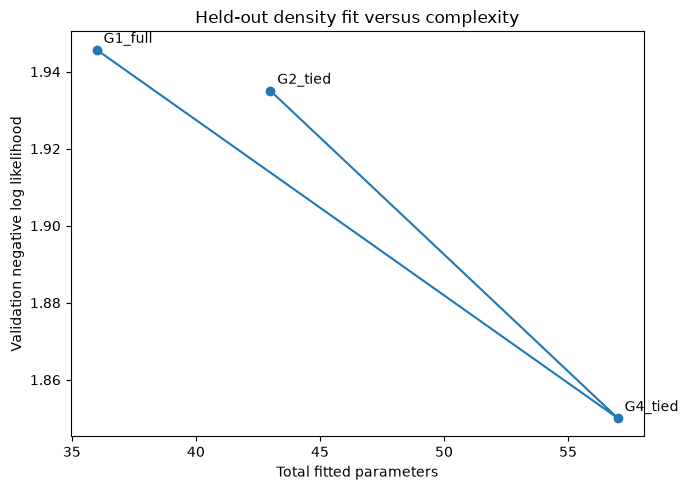

Saved: /ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/outputs/gmm_quadratic/figures/density_accuracy_vs_complexity.png


In [10]:
plt.figure(figsize=(7, 5))

plt.plot(
    comparison["total_parameters"],
    comparison["validation_nll"],
    marker="o",
)

for _, row in comparison.iterrows():
    plt.annotate(
        row["model"],
        (
            row["total_parameters"],
            row["validation_nll"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.xlabel("Total fitted parameters")
plt.ylabel("Validation negative log likelihood")
plt.title("Held-out density fit versus complexity")
plt.tight_layout()

density_plot = (
    FIGURE_DIR
    / "density_accuracy_vs_complexity.png"
)

plt.savefig(
    density_plot,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", density_plot)

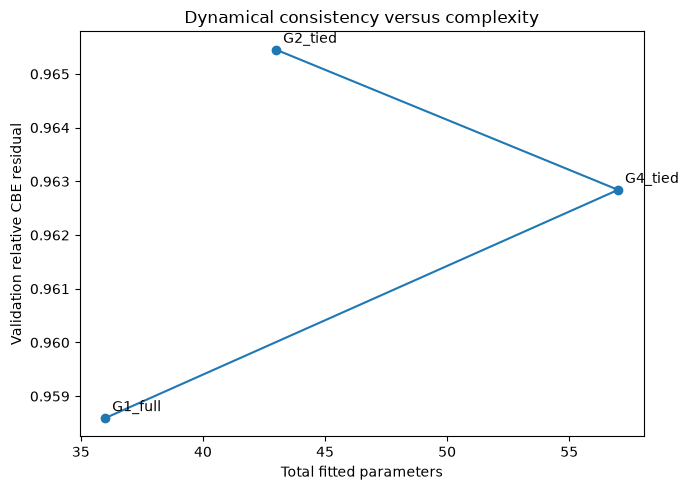

Saved: /ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/outputs/gmm_quadratic/figures/cbe_residual_vs_complexity.png


In [11]:
plt.figure(figsize=(7, 5))

plt.plot(
    comparison["total_parameters"],
    comparison["validation_relative_cbe"],
    marker="o",
)

for _, row in comparison.iterrows():
    plt.annotate(
        row["model"],
        (
            row["total_parameters"],
            row["validation_relative_cbe"],
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )

plt.xlabel("Total fitted parameters")
plt.ylabel("Validation relative CBE residual")
plt.title("Dynamical consistency versus complexity")
plt.tight_layout()

cbe_plot = (
    FIGURE_DIR
    / "cbe_residual_vs_complexity.png"
)

plt.savefig(
    cbe_plot,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Saved:", cbe_plot)

In [12]:
print("GMM + QUADRATIC POTENTIAL BASELINE COMPLETE")
print("=" * 70)

display(
    comparison[
        [
            "model",
            "total_parameters",
            "validation_nll",
            "validation_relative_cbe",
            "validation_cbe_r2",
            "laplacian_psi",
        ]
    ]
)

print("\nNo test stars were used.")
print("Comparison saved to:")
print(comparison_path)

print("\nPotential equations saved to:")
print(equation_file)

GMM + QUADRATIC POTENTIAL BASELINE COMPLETE


,model,total_parameters,validation_nll,validation_relative_cbe,validation_cbe_r2,laplacian_psi
0,G1_full,36,1.945694,0.958592,0.081101,1.702652
1,G4_tied,57,1.850060,0.962842,0.072936,1.549408
2,G2_tied,43,1.935068,0.965451,0.067905,1.677471



No test stars were used.
Comparison saved to:
/ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/outputs/gmm_quadratic/model_comparison.csv

Potential equations saved to:
/ocean/projects/cis240096p/idas/iaifi_summer_school/gaia_project/outputs/gmm_quadratic/potential_equations.txt
